In [1]:
import pandas as pd

In [2]:
df  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/test_results.csv')
new_model = df.sort_values(by=['similarity_score'], ascending=False)

In [3]:
df2  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/test_results_rag.csv')
rag_model = df2.sort_values(by=['similarity_score'], ascending=False)

In [4]:
df3  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/test_results_rag_MultiQuery.csv')
mq_model = df3.sort_values(by=['similarity_score'], ascending=False)

In [5]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('Rag Model Similarity:', rag_model['similarity_score'].mean())

# 2 * (number of matching characters)/ (total characters in both strings)
print('New Model Similarity:', new_model['similarity_score'].mean())

# 2 * (number of matching characters)/ (total characters in both strings)
print('Rag MQ Model Similarity:', mq_model['similarity_score'].mean())

Rag Model Similarity: 0.9191333333333334
New Model Similarity: 0.8614666666666667
Rag MQ Model Similarity: 0.9068666666666667


In [17]:
new_model.tail(10)

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
51,52,Return top 1.0 rows by power_OBS.,"df.nlargest(1.0, 'power_OBS')",df.loc[df['power_OBS'].rank(pct=True).nlargest...,0.35,False,False,NaN
8,9,Return bottom 111.0 rows by power_OBS.,"df.nsmallest(111.0, 'power_OBS')",df.loc[df['power_OBS'].rank(ascending=False).a...,0.33,False,False,NaN
58,59,Return top 64.0 rows by day_ahead.,"df.nlargest(64.0, 'day_ahead')",df.loc[df['day_ahead'].isin(df['day_ahead'].va...,0.33,False,False,NaN
60,61,Return bottom 77.0 rows by power_OBS.,"df.nsmallest(77.0, 'power_OBS')",df.loc[df['power_OBS'].rank(ascending=False).a...,0.33,False,False,NaN
131,132,Return top 56.0 rows by day_ahead.,"df.nlargest(56.0, 'day_ahead')",df.loc[df['day_ahead'].isin(df['day_ahead'].va...,0.30,False,False,NaN
46,47,Return bottom 88.0 rows by day_ahead.,"df.nsmallest(88.0, 'day_ahead')","df.loc[df['day_ahead'].rank(method='dense', as...",0.30,False,False,NaN
140,141,Return top 89.0 rows by day_ahead.,"df.nlargest(89.0, 'day_ahead')",df.loc[df['day_ahead'].isin(df['day_ahead'].va...,0.30,False,False,NaN
121,122,Return bottom 34.0 rows by day_ahead.,"df.nsmallest(34.0, 'day_ahead')",df.loc[df['day_ahead'].isin(df['day_ahead'].va...,0.29,False,False,NaN
92,93,Return top 194.0 rows by power_OBS.,"df.nlargest(194.0, 'power_OBS')",df.loc[:193],0.28,False,False,NaN
44,45,Return bottom 38.0 rows by pred.,"df.nsmallest(38.0, 'pred')",df.loc[df['pred'].rank(ascending=False).argsor...,0.25,False,False,NaN


In [18]:
num = 132

In [19]:
print(new_model[new_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(new_model[new_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(new_model[new_model['test_case_id'] == num]['generated_output'].values[0])

Return top 56.0 rows by day_ahead.
------------------
df.nlargest(56.0, 'day_ahead')
-----
df.loc[df['day_ahead'].isin(df['day_ahead'].value_counts().index[:56])].tail()


In [20]:
print(rag_model[rag_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(rag_model[rag_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(rag_model[rag_model['test_case_id'] == num]['generated_output'].values[0])

Return top 56.0 rows by day_ahead.
------------------
df.nlargest(56.0, 'day_ahead')
-----
df[df['day_ahead'] == 56.0].head(5)


In [21]:
print(mq_model[mq_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(mq_model[mq_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(mq_model[mq_model['test_case_id'] == num]['generated_output'].values[0])

Return top 56.0 rows by day_ahead.
------------------
df.nlargest(56.0, 'day_ahead')
-----
df[df['day_ahead'] == 56.0].head(5)


In [ ]:
## Taking the mean of a boolean/binary column gives you accuracy
print('New Model:', new_model["is_correct"].mean().round(4))
print('Rag Model:', rag_model["is_correct"].mean().round(4))
print('Rag MQ Model:', mq_model["is_correct"].mean().round(4))

New Model: 0.66
Rag Model: 0.8333
Rag MQ Model: 0.8267


In [29]:
## Taking the mean of a boolean/binary column gives you accuracy of method correctness
print('New Model:', new_model["method_correct"].mean().round(4))
print('Rag Model:', rag_model["method_correct"].mean().round(4))
print('Rag MQ Model:', mq_model["method_correct"].mean().round(4))

New Model: 0.8
Rag Model: 0.8733
Rag MQ Model: 0.84


In [ ]:
'### When the model is wrong, how close was it to being right?'
print('New Model:', new_model.loc[~new_model["is_correct"], "similarity_score"].mean())
print('Rag Model:', rag_model.loc[~rag_model["is_correct"], "similarity_score"].mean())
print('Rag MQ Model:', mq_model.loc[~mq_model["is_correct"], "similarity_score"].mean())

New Model: 0.61
Rag Model: 0.5176000000000001
Rag MQ Model: 0.46499999999999997


In [ ]:
### When the model method is wrong, how close was it to being right?
print('New Model:', new_model.loc[~new_model["method_correct"], "similarity_score"].mean())
print('Rag Model:', rag_model.loc[~rag_model["method_correct"], "similarity_score"].mean())
print('Rag MQ Model:', mq_model.loc[~mq_model["method_correct"], "similarity_score"].mean())

New Model: 0.4723333333333333
Rag Model: 0.40315789473684216
Rag MQ Model: 0.4320833333333334


In [ ]:
## Near Miss Rate: Proportion of incorrect responses with similarity score between 0.8 and 0.89
near_miss_rate_rag = (
    rag_model.loc[~rag_model["is_correct"], "similarity_score"]
    .between(0.8, 0.89)
    .mean()
)

near_miss_rate_mq = (
    mq_model.loc[~mq_model["is_correct"], "similarity_score"]
    .between(0.8, 0.89)
    .mean()
)
    

near_miss_rate = (
    new_model.loc[~new_model["is_correct"], "similarity_score"]
    .between(0.8, 0.89)
    .mean()
)

print('New Model:', near_miss_rate)
print('Rag Model:', near_miss_rate_rag)
print('Rag MQ Model:', near_miss_rate_mq)

New Model: 0.3137254901960784
Rag Model: 0.24
Rag MQ Model: 0.07692307692307693


In [ ]:
## Percentage of predictions where the model is meaningfully off-target
print('New Model:', (new_model["similarity_score"] < 0.7).mean())
print('Rag Model:', (rag_model["similarity_score"] < 0.7).mean())
print('MQ Model:', (mq_model["similarity_score"] < 0.7).mean())

New Model: 0.2
Rag Model: 0.12666666666666668
MQ Model: 0.16


In [57]:
# This is a task-level performance breakdown. It tells you which kinds of instructions your model struggles with vs excels at
models = {
    "new": new_model,
    "rag": rag_model,
    "mq": mq_model,
}

summary = (
    pd.concat(
        {
            name: df.assign(
                task_type=df["instruction"].str.split().str[0]
            )
            .groupby("task_type")
            .agg(
                accuracy=("is_correct", "mean"),
                avg_similarity=("similarity_score", "mean"),
                count=("test_case_id", "count"),
            )
            for name, df in models.items()
        },
        names=["model"]
    )
    .sort_values(["model", "accuracy"])
)

summary.reset_index()

,model,task_type,accuracy,avg_similarity,count
0,mq,Count,0.000000,0.706667,6
1,mq,Return,0.130435,0.470000,23
2,mq,Compute,1.000000,0.999630,54
3,mq,Extract,1.000000,1.000000,8
4,mq,Filter,1.000000,1.000000,46
5,mq,Get,1.000000,1.000000,5
6,mq,Sort,1.000000,1.000000,8
7,new,Extract,0.000000,0.810000,8
8,new,Return,0.173913,0.495652,23
9,new,Compute,0.722222,0.937037,54


In [58]:
# This line creates a weighted, holistic model score that:
# 	•	values being right
# 	•	values using the right method
# 	•	values being close when wrong

final_score = (
    0.3 * new_model["is_correct"].mean() +
    0.4 * new_model["method_correct"].mean() +
    0.3 * new_model["similarity_score"].mean()
)

print('New Model:', final_score)

New Model: 0.77644


In [59]:
final_score = (
    0.3 * rag_model["is_correct"].mean() +
    0.4 * rag_model["method_correct"].mean() +
    0.3 * rag_model["similarity_score"].mean()
)

print('RAG Model:', final_score)

RAG Model: 0.8750733333333333


In [60]:
final_score = (
    0.3 * mq_model["is_correct"].mean() +
    0.4 * mq_model["method_correct"].mean() +
    0.3 * mq_model["similarity_score"].mean()
)

print('RAG MQ Model:', final_score)

RAG MQ Model: 0.85606


In [61]:
cols = ["test_case_id", "is_correct", "similarity_score", "method_correct"]

new2 = new_model[cols].sort_values("test_case_id").reset_index(drop=True)
base2 = rag_model[cols].sort_values("test_case_id").reset_index(drop=True)
mq2 = mq_model[cols].sort_values("test_case_id").reset_index(drop=True)

assert (new2["test_case_id"] == base2["test_case_id"]).all()

In [62]:
# from scipy.stats import ttest_rel

# t_stat, p_value = ttest_rel(
#     new2["similarity_score"],
#     base2["similarity_score"]
# )

# t_stat, p_value

In [63]:

# import numpy as np
# diff = new2["similarity_score"] - base2["similarity_score"]

# boot_means = []
# rng = np.random.default_rng(42)

# for _ in range(10000):
#     sample = rng.choice(diff, size=len(diff), replace=True)
#     boot_means.append(sample.mean())

# ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
# mean_diff = diff.mean()

# mean_diff, ci_low, ci_high

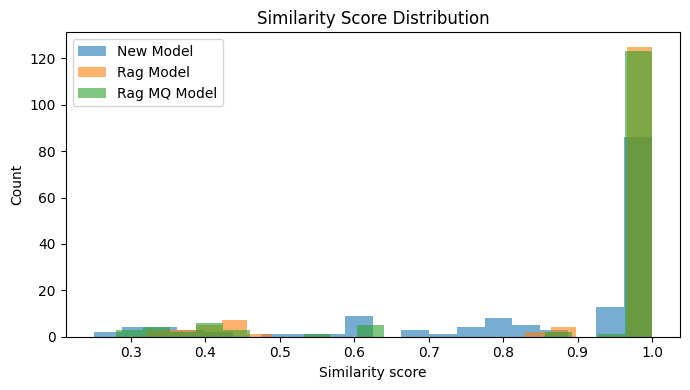

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(new2["similarity_score"], bins=20, alpha=0.6, label="New Model")
plt.hist(base2["similarity_score"], bins=20, alpha=0.6, label="Rag Model")
plt.hist(mq2["similarity_score"], bins=20, alpha=0.6, label="Rag MQ Model")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.legend()
plt.title("Similarity Score Distribution")
plt.tight_layout()
plt.show()

In [65]:
# diff = new2["similarity_score"] - base2["similarity_score"]

# plt.figure(figsize=(10,4))
# plt.hist(diff, bins=25)
# plt.axvline(0, linestyle="--")
# plt.xlabel("Similarity(New Model) − Similarity(Rag Model)")
# plt.ylabel("Count")
# plt.title("Per-Test-Case Similarity Difference")
# plt.tight_layout()
# plt.show()

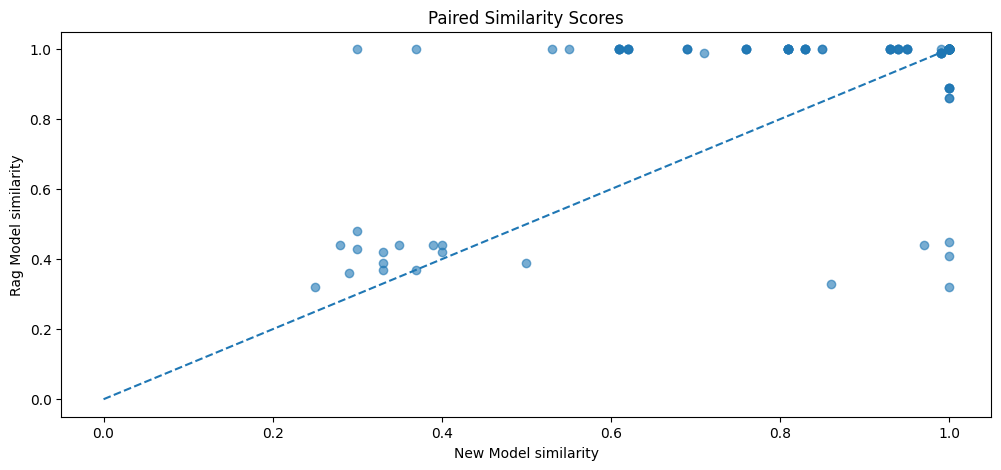

In [66]:
plt.figure(figsize=(12,5))
plt.scatter(
    x= new2["similarity_score"],
    y= base2["similarity_score"],
    alpha=0.6,
)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("New Model similarity")
plt.ylabel("Rag Model similarity")
plt.title("Paired Similarity Scores")
# plt.tight_layout()
plt.show()

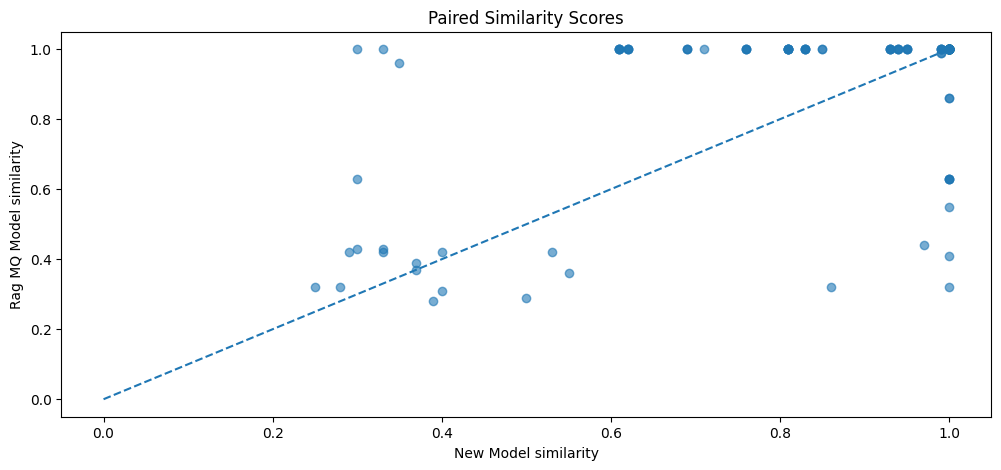

In [68]:
plt.figure(figsize=(12,5))
plt.scatter(
    x= new2["similarity_score"],
    y= mq2["similarity_score"],
    alpha=0.6,
)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("New Model similarity")
plt.ylabel("Rag MQ Model similarity")
plt.title("Paired Similarity Scores")
# plt.tight_layout()
plt.show()

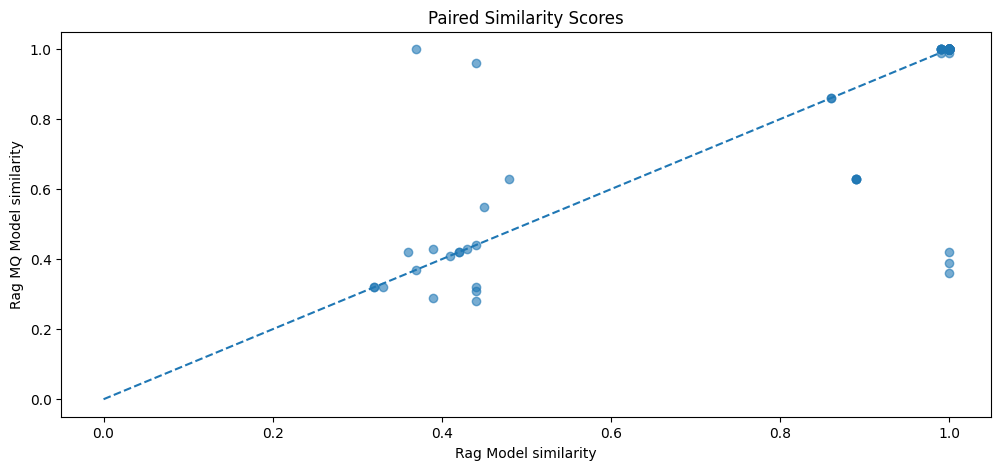

In [69]:
plt.figure(figsize=(12,5))
plt.scatter(
    x= base2["similarity_score"],
    y= mq2["similarity_score"],
    alpha=0.6,
)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Rag Model similarity")
plt.ylabel("Rag MQ Model similarity")
plt.title("Paired Similarity Scores")
# plt.tight_layout()
plt.show()

In [70]:
# a_only = ((new2.method_correct) & (~base2.method_correct)).sum()
# b_only = ((~new2.method_correct) & (base2.method_correct)).sum()
# both = ((new2.method_correct) & (base2.method_correct)).sum()
# neither = ((~new2.method_correct) & (~base2.method_correct)).sum()

# plt.figure(figsize=(10,4))
# plt.bar(
#     ["New Model only correct", "Rag Model only correct", "Both correct", "Both wrong"],
#     [a_only, b_only, both, neither]
# )
# plt.ylabel("Count")
# plt.title("Accuracy Agreement Breakdown (Method Correct)")
# plt.tight_layout()
# plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_84505/1456550778.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([err_new, err_base, err_mq], labels=["New Model", "Rag Model", "Rag MQ Model"])


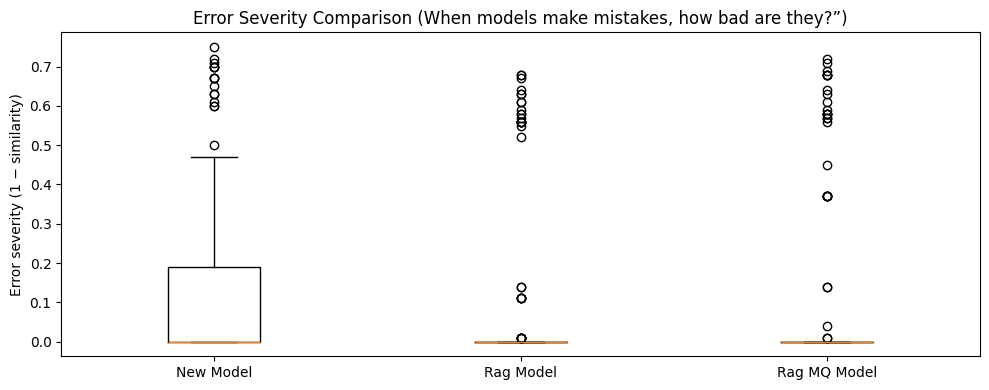

In [73]:
err_new = 1 - new2["similarity_score"]
err_base = 1 - base2["similarity_score"]
err_mq = 1 - mq2["similarity_score"]

plt.figure(figsize=(10,4))
plt.boxplot([err_new, err_base, err_mq], labels=["New Model", "Rag Model", "Rag MQ Model"])
plt.ylabel("Error severity (1 − similarity)")
plt.title("Error Severity Comparison (When models make mistakes, how bad are they?”)")
plt.tight_layout()
plt.show()

In [72]:
# plt.figure(figsize=(10,4))
# plt.hist(diff, bins=30)
# plt.axvline(0, linestyle="--")
# plt.axvline(diff.mean())
# plt.title("Model New vs RAG — Per-Case Quality Difference")
# plt.xlabel("Similarity difference (New − RAG)")
# plt.tight_layout()
# plt.show()

In [75]:
new_model["task_type"] = (
    new_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group|return)')
    .fillna("other")
)

rag_model["task_type"] = (
    rag_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group|return)')
    .fillna("other")
)

mq_model["task_type"] = (
    mq_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group|return)')
    .fillna("other")
)

In [81]:
task_stats_new = (
    new_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
)

task_stats_new

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
compute,0.722222,0.937037,0.277778,0.062963,54
extract,0.000000,0.810000,1.000000,0.190000,8
filter,0.804348,0.916957,0.195652,0.083043,46
other,1.000000,1.000000,0.000000,0.000000,11
return,0.173913,0.495652,0.826087,0.504348,23
sort,1.000000,0.945000,0.000000,0.055000,8


In [80]:
task_stats_base = (
rag_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
)

task_stats_base

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
compute,1.000000,0.998704,0.000000,0.001296,54
extract,1.000000,1.000000,0.000000,0.000000,8
filter,1.000000,1.000000,0.000000,0.000000,46
other,0.454545,0.934545,0.545455,0.065455,11
return,0.173913,0.506957,0.826087,0.493043,23
sort,1.000000,1.000000,0.000000,0.000000,8


In [79]:
task_stats_mq = (
mq_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
)

task_stats_mq

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
compute,1.000000,0.99963,0.000000,0.00037,54
extract,1.000000,1.00000,0.000000,0.00000,8
filter,1.000000,1.00000,0.000000,0.00000,46
other,0.454545,0.84000,0.545455,0.16000,11
return,0.130435,0.47000,0.869565,0.53000,23
sort,1.000000,1.00000,0.000000,0.00000,8


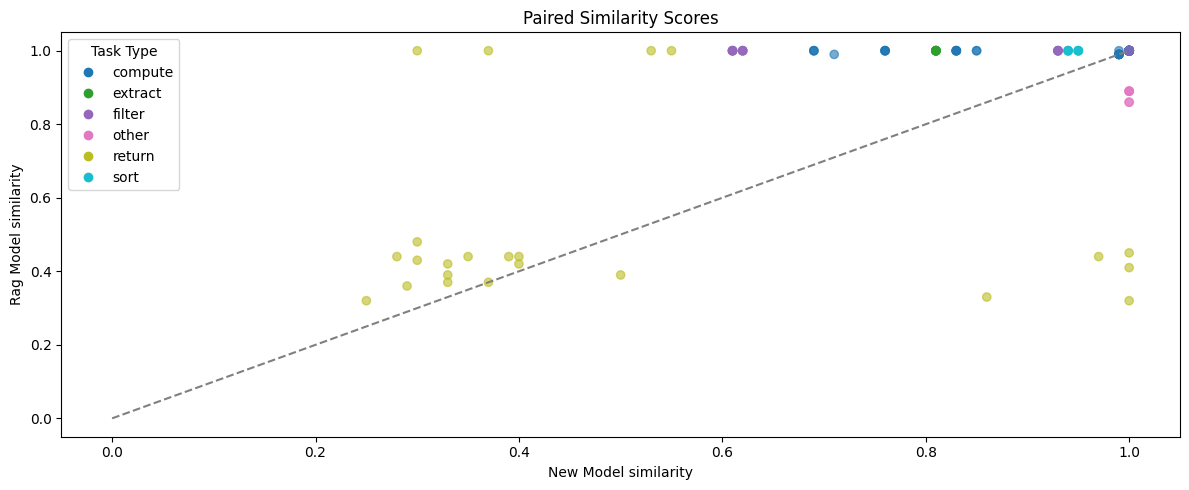

In [83]:
new_model2 = new_model.sort_values('test_case_id').reset_index(drop=True)
base_model2 = rag_model.sort_values('test_case_id').reset_index(drop=True)
mq_model2 = mq_model.sort_values('test_case_id').reset_index(drop=True)
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = new_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=new_model2["similarity_score"],
    y=base_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("New Model similarity")
plt.ylabel("Rag Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()

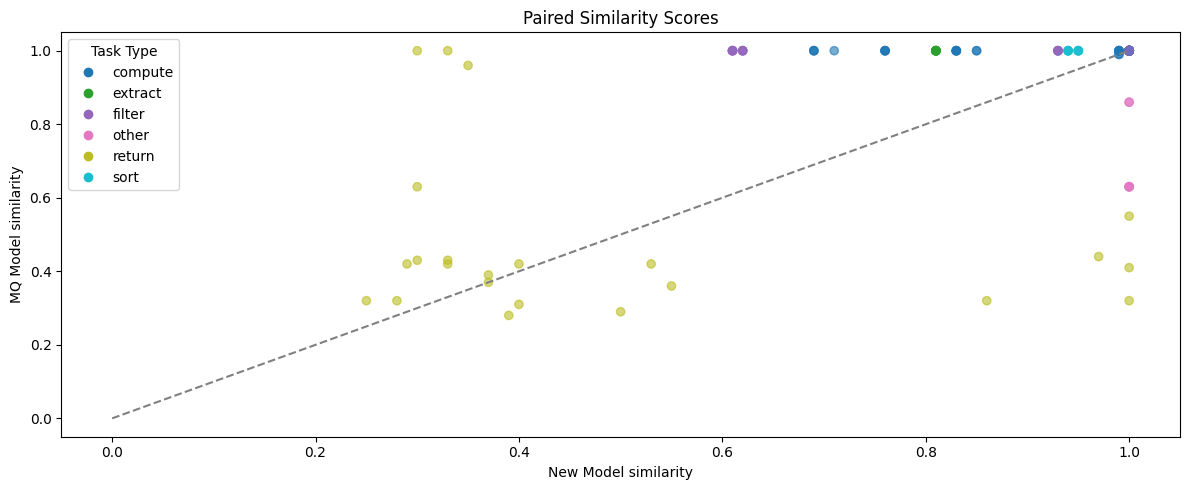

In [84]:
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = new_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=new_model2["similarity_score"],
    y=mq_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("New Model similarity")
plt.ylabel("MQ Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()

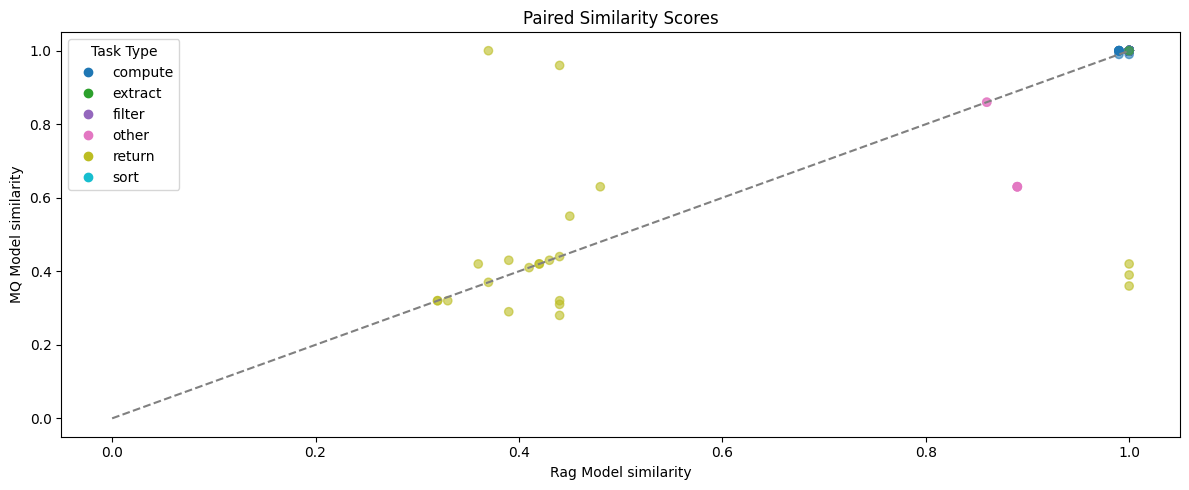

In [85]:
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = base_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=base_model2["similarity_score"],
    y=mq_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("Rag Model similarity")
plt.ylabel("MQ Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()

In [97]:
mq_model[mq_model['test_case_id'].isin([141,59,130,83])]

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error,task_type
140,141,Return top 89.0 rows by day_ahead.,"df.nlargest(89.0, 'day_ahead')","df.nlargest(89.0, 'day_ahead')",1.00,True,True,NaN,return
58,59,Return top 64.0 rows by day_ahead.,"df.nlargest(64.0, 'day_ahead')","df.nlargest(64.0, 'day_ahead')",1.00,True,True,NaN,return
129,130,Return bottom 76.0 rows by gain.,"df.nsmallest(76.0, 'gain')",df.loc[:76.0],0.41,False,False,NaN,return
82,83,Return top 112.0 rows by gain.,"df.nlargest(112.0, 'gain')",df.loc[:111],0.32,False,False,NaN,return


In [96]:
rag_model[rag_model['test_case_id'].isin([141,59,130,83])]

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error,task_type
140,141,Return top 89.0 rows by day_ahead.,"df.nlargest(89.0, 'day_ahead')","df.nlargest(89.0, 'day_ahead')",1.00,True,True,NaN,return
129,130,Return bottom 76.0 rows by gain.,"df.nsmallest(76.0, 'gain')",df.loc[:76.0],0.41,False,False,NaN,return
58,59,Return top 64.0 rows by day_ahead.,"df.nlargest(64.0, 'day_ahead')",df.loc[:64.0],0.37,False,False,NaN,return
82,83,Return top 112.0 rows by gain.,"df.nlargest(112.0, 'gain')",df.loc[:111],0.32,False,False,NaN,return


In [95]:
new_model[new_model['test_case_id'].isin([141,59,130,83])]

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error,task_type
129,130,Return bottom 76.0 rows by gain.,"df.nsmallest(76.0, 'gain')","df.nsmallest(76.0, 'gain')",1.00,True,True,NaN,return
82,83,Return top 112.0 rows by gain.,"df.nlargest(112.0, 'gain')","df.nlargest(112.0, 'gain')",1.00,True,True,NaN,return
58,59,Return top 64.0 rows by day_ahead.,"df.nlargest(64.0, 'day_ahead')",df.loc[df['day_ahead'].isin(df['day_ahead'].va...,0.33,False,False,NaN,return
140,141,Return top 89.0 rows by day_ahead.,"df.nlargest(89.0, 'day_ahead')",df.loc[df['day_ahead'].isin(df['day_ahead'].va...,0.30,False,False,NaN,return
